<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #7c3aed; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Clustering Jerárquico Aglomerativo 🌳
      </h1>
      <p style="margin: 6px 0 0 0; color: #7c3aed; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Hierarchical Clustering — Dendrogram Analysis
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #7c3aed; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 03 • Data Mining
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #7c3aed; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/01_Clustering_Jerarquico_Aglomerativo.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## 1. Clustering Jerárquico: Principios y Criterios de Enlace 🌳

El clustering jerárquico construye una **jerarquía de particiones** anidadas representada por un **dendrograma**. No requiere especificar $K$ de antemano; la estructura del árbol permite cortar a diferentes niveles y obtener cualquier número de clusters.

### 1.1 Enfoque Aglomerativo (Bottom-Up)

1. Comienza con $n$ clusters singleton (cada observación es su propio cluster).
2. En cada paso, une los dos clusters más similares según el **criterio de enlace** (*linkage*).
3. Repite hasta que todos los puntos forman un único cluster.

**Complejidad:** $O(n^2 \log n)$ con el algoritmo de Lance-Williams.

### 1.2 Criterios de Enlace

| Criterio | Definición | Ventaja | Desventaja |
|----------|-----------|---------|-----------|
| **Single** | $d(A, B) = \min_{a \in A, b \in B} d(a, b)$ | Detecta clusters elongados | Efecto cadena (*chaining*) |
| **Complete** | $d(A, B) = \max_{a \in A, b \in B} d(a, b)$ | Clusters compactos | Sensible a outliers |
| **Average (UPGMA)** | $d(A, B) = \frac{1}{|A||B|} \sum d(a, b)$ | Balance entre los dos anteriores | Moderadamente robusto |
| **Ward** | Minimiza el incremento en WCSS | Clusters esféricos de tamaño similar | Supone clusters globulares |

> **Regla práctica:** `Ward` es el default recomendado para datos continuos estandarizados; es el que mejor replica los resultados de K-Means en clusters globulares y produce dendrogramas más balanceados.

### 1.3 Distancia de Corte (Truncation Height)

La altura $h$ en la que se "corta" el dendrograma determina el número de clusters:
$$K = \text{número de ramas que cruzan la línea } y = h$$

Se elige $h$ donde hay un **salto grande** en la altura de fusión (análogo al codo en K-Means).


In [1]:
# ─── Celda 1: Carga de datos y estandarización ───────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import os, sys, urllib.request, urllib.parse, gzip, base64

# ─── Datos embebidos (fallback sin conexión a GitHub) ─────────────────────────
_DATA_EMBEDDED = {
    "segmentacion_clientes_tienda.csv": "H4sIAAq1mGoC/21dS69uR06dI/FPDtJ2vT1mygwYR1F31IqANCJpfj/ltfZ328uH6CqDqv3V0+Xnss+vf/7pT//56y+//fHL1y9//vnPX7/+9pf/+eX3v/70829/+/k/f/qPn/72+5+//vtvv/3xt5//9Otff/vpLz///sdfv/73199//ePn33/6r19++/1+9svv//gP//wv//6v//ZPz/3Pvtr6sra/9vlauaN9zf3lt3F+tdzev2b7au3LxlfP7eNr9K9jX/Nr5+YZ367+5fPLcvv66s+X2RMdMv7+WnfwfuceXzN3nK+x70pb9MsvPFZq/U4gO7hjL7bf6fNIdhd593x3Ev254w680dEeHeoO4HfuE3scuePu+vm67WfqD2Y07hWbyKdk66thuaPpknYcx7D4XlZ0sLd7Rcv1B/61Fs5vD1lRrLzHSOdou8UPTvvqLqcX53mwtXus8oP+1fud4a71yNRtBMmcuwBtnrHGWOrWPd+Whksdem+3cSxQTBn/xPh3meWs4+CeINO76TwOD87uYo+eUbcg1X7iN3mg3uJyYn96FHeESxdB2l020AcI5Z7E1lu+pBVEfAkwVps7VpAFSNK0Aze/77kubT8xxV1wL1N7tFwSWI+039Hvu4yZXQe6J3HHutc8dW+DpH0qudwzvsdvl16nyeGNEdPGYUxtv3tecU7n0fYVhx2k14UB3Dd7f3KpMq47t5+Y+GwceW6/NOTReHecv79Xf+n0rLrhu+wBQtp6QhP869LM7c3rnHj1d5Cjn2O7dtlhYRYTDOyAuPLd3xXerng3++vJ7TuOPt6f6QR3vnuYZpWv3a/vmu5pNhn/br894IOmB7cM5H479SbvA8NNrng9eYK7oUsrl+a2bnmNaA9y1Hd5G29XUKQLL7rsY0IcKEHc07w9PZpl9IPDn19+jyK3X7qcOEwl0Lg+w8Qy+rYY2kJc6CO+i14GduN6DnejcYWXjwodBlPa8TDKMBMvtQUD0e/JCe4xH2VnG8/ovvutMmKDg/oTTCpveHusx57bKt/fG7+EbsFrlNIPuEAsaegTO5C7d/47ZF7RASfbEAX5wu7C70pDAnVtn3E1wReV2dzH1RdWNJUW7ysNBtdioHxnV8SEWOygLpnBeTlg1/kXjldsD15g3tulkktZ7nFJeU1+Jx2UKvq+Hedm/ZtkjOdF6T506hnUGFy88NK7knhMM95g3oSD/d2TuseaL/TqRDPuZ4Jgc4fHE7+Tx1R/b4+rjz3cc1WdCdzG8GTvpbbcAU6KzcmasKsVr2SJzLSrfQUJ35lCVcgddylxRfcahv5iQYEAq31yO84nKDk/B7vaV3DCjdeY2z0mDvYrNBmKyb2eS8pNt3z5X6h2Pc4uj3NVr7srCPGuP+hkABNcJncMbODOskQihCwDjc3gk3nL95yDNY+g8nzalyQuu2i4JRkILKzzX27HWxiQCvmsg4p2KH1NFJd4yZcu+ioEFqpscP4WS8rrvD9veKL70fYRVBpMQS+fmteG4Ml3Ri0qtJ2l34NjH5C3tOOO7zhHBIU1KCEbOk3e1z16KEtP0X6tQ4rejamos3gdBvXedKAeC7r3r+d8r4PrMRFQwW9C4+6xLxkG9BzHd8k9HzS1rrhgXeZ5pd996fnc7qHdq4/Vmsg0i/1DAg6xG+zSWeMp6+eNOoUHeeWJr4rU8PTLmxx41y20blnQgA7SqnZoAzIqzC5lH3d598vLOlUg2F18WEMTBkhu93jzwdeazDufD/Nd+jImNOtVVXQLdXvSqmuy0okdbxiI8gPs+NL50BO69x6LXSFP5fsV7fH2Vde30PUWrMOggtxxMFKIcv2BQ5iCX+cZ7kFMqA961OsVyjvEez7rBVUbNqPrQNCsQ6wcbYc8vlsujO5eS9ApHnI+iuBuG0qKcvardw1yj0cu7Z5n8EVq3LJSx9lRlOYj2jCU/RSj1Db41oAJKu24eg/LR3awsePLDroIfdt4x/EKlW9d3eu2h7AWzcg2xV61beweTIcNZlvnBeFOGBTS7uBYXgXEZcPQTsB489EdKKAhOU7pAJlcbqDWk90rHMHNQlpKOyzGCdNZ2icUKfBlGR8vLFZ0ykA7REFIqKO88cBIJq/OZ3rA8C/BqIjzH/aiKpvmkMfBCguvuA/4HurtLsqMU7cOJqUzO0ToPVs1AM1hWo5RlEcLBZAcsLTvaOnVMDSyp1AgTJ/+VbuC9YILpvb2QBxPWBort1ssMaSLyo/2QNsLOm1y2O2BQyW49tAfDDzxoYfdHpjI8W7K5yvobuH2ZUH7h6dFv4e7Kc7v6HJA15witxtsD/Oi4Lbwd8HqKvs1EEoojfelPLmj4+GAvmSgAQ3wYPrcPnGJM8zzvDHDEtssLK29OrgV3tvCrvo8j3yT3NIljCMKdwtfF5w/Xdd/RU0IkFWeX2tQMi8DaSKoWxAztTwxGVqDdy9MGLFh2/15SEpsTb5fuHK8Ysvt4OuhYzZtP2B0oUd1HchBic+sM9xPJ7xX6tJqnV60Vby4rTd6EWaxC1p4lQwPTazVRp3LIHilHdr0pcVeJqAbBFefjzTMOLKJPvQHECdjFQHeqHSFJia6SQv3aggPD6MhDzQgnTas2DzQPf6QZlV5a/cphQ9yFobWxni1wDH0exz+5VKXB+YrGLA449LuQPmIBm45Jn50Avj2YC9uHQncGB6k3DwfOgwarIbcgR0fqIfygwZn5lMctS30GKgZLp7dFoQIvWuV7yeUmyq12qR06tBmZGJc5GX85UgnDIl7X65XM/EIwoPY5b0uCOQQpvJ5eLo8FMqhJLFA1Pe6/NHvITb6LhKlhcZFV7Dp9/AIDNiiMj5oOq5d1Px2b5G2rgrptl798hu/WeAom26VvOEw7AZ9ePoKNp17D3wL+e5DUZ3QNAqZboQm+C9vekM23SNp+mw2ePU9UVcZt+HdMxCFjAMN5O7PlXcF94NvbChxbXhcN5TJPO9VDOhDMqWJYOkO1UcvJ1Qucq69tKO/73WKz6mFzkWeqWZqO7TXHtBL3vIBu96QdLLU/ToD1KxqB4LAYezJBJBZ4VGZokA3x/2GCDxZJWpudDpS08kdNF/ohc5LCodJi1erqm/zweiNFwutOR5ZuG309Hy9uoOV76GuhvlcJjj0RCGsIB14y/MU91u/2oQxnqQO1X431eEa0T33CDTC+S5KUWec0U6h9x5xRuqGS4efeGtedJb+IFgRD8fKQuEFoaFp8guoXZeC1YPfqTzf7R4Rjd1A2UFfXfhRN1xjr3y8G2y2Ds0ib+EeWNgl96C2MJgeri6oOvoUuoFhR1Bs6kArTi1WpKpvD09XgxvKdAJ4uu5l+tGVQrWGh0fosd/3MaGIq0rZw0dBTVlU4t5wyUEYW9sRag3Z6BJV6CGgDD7TI8+8h7OLnk71mvWGEEH4nYYuace7OSA9GeiAwYRjZeoPHJaPF47XKavDw6B76HRpXeLeehhhiMH4XKKJ9A5/PdQ+2UHoXh773UMngD1x/19up8PqoR4k7fBnzmpM9g5GZP5tfF69x2PI47xEOovLo4ctxLC+Hlxw/IWr6U1/8OMVbP0BnowxUJ7bJ/RixDGlfYHea5S8j/06TE2vOMQxLnOW76mHmMaa+nzeGIS6M3uYqfYGsOV7hM5XDXL0CZd1WCbKDybMidWKF6HTVtlwgsr39Gfec1t6AXMz9jGKJtjDUIRhLs71Pj8xt8IzFyRBh0DNF0/Fa5OuczudqGBT+YBCWNHjrsp7X/TRh2Lf9BcIS0QUeeoM1ELCUtazXrA7SbsyAxWNVnzEnapXBPhVHIS0b7AjxVnQ72bn82I55Hs4wM4pPqS+IcdCSa8/oM2IIFDW+fqedC5BicxL3YvuqK52QN/0WsPqyme3sZg4JpWM2z/iQ+MV/dD5c7ngVi5+GDu3UHTyUgMl8iAGr5cQQuCJj03pIlQvuq9C588d8xOZ10M6oLqQRkcXtN8okwal+oEacMa3ncEDHW5lfTmOe7zvU0/I4d9zL4ZSd3CIsD21mcLpwa7zMh1YJzhsSgd8XQgyy0DgW8EYp3KKOyUtOnXIdwephwE79XtE1NcoNu8IlrtBcaJbjQeOEIZvpR3B89ZLbHs8wPzQztm5fXxM0rG1Y4KaB4y33L5gPN/dZkIZoXPRozh0/RDc4YuU8xwP4sHfAhzD4GUMWSASaxgYVzwBtQGGtRdftYXSxz2vBsnkZQKoH9G+dJzJiDfMobyDcM4jdNOGDrTfOKiCn4bBWx1nd3QHDmMBobP8fYPFSJM6L6hhx2EL6ziEycV7Mh2HSLa+ixEzIk47Q9iro3k0POGIee4yw4LV+1Sn+GiwwSNGo0CwEe4uI/QmH11zslIPhpbXyvhih7aRqSLM+I1LULYyOt7xwqPKK+qglfYU5ODo2POd3CVmNF6Fy4uQGB2XHFJr6Pf7lWZ3e5m6OvARgY3QZ8mQcsSjj7z78cZ2a2R5hE/gwAl2lK4Zhx7QWvKKBlwhRvhTnnpAMRy9qEQjjrhBUm+xw8eA4txgjcnMGwr1DFqVCeDtCuqdOg50LsCTlHfNh1qjVXIJyiUCSmMWgwpdQMHErTxCGT40G3Qg7DmMf+GmY2LPbRQ/z5ig7I6oWGZ2Ez7NBaEp88L/MxEalHkRYgw4ngy/aC8aZF0+iQV7kRAfaYeScbyoaSPAdhNPs9ApHV4DJJ83sBBta3hQ+UAXEDAOtVXaN1BasKllHNA1tUGZF8zLdmWCG5GYUCmU3Le9fsKpF7MJML7SSMzXEeqLfzB0+SQ2Vb1TQHpjvwDNVoKn49W5Orxq0rEBM3Q4hHM7HGPUWKQdQKr7jNX/Mg749eUTakQOSoIxi604TqNXuZdw8ThAM4TG4doOR+rB9eSzOwgXAZeoLOHg5jvUk3xpB07cFdpnvuNQeeFuKsR4YFAhmKs8yqE+O0gm341DP4g7cLFihmPLQTP6PS+5wYGVZ3YqIY0gjNwBhHfolPoufX2w7RprGM54OlEE+VAdTs05qh7irx9kIQ74944ZgCsDU85bm499eJrqRfOhETlC15F2sNhRFdz5AKMZtF0moGpIoyW3Q2cHXFKubT54lMEr1P02H8ibVfn1fIgWIFgrT2HQuhwe6rykV/cK7IfrDxBJvpJCwxDTyL6eWaCdk8oX4/krt8PpENcWwd7cAYjEgpR/cjsU3+B3suUIMw6Yz3VFMBfpJMtbCyzFgDNVUWuzwTNgs8jx2QAKCdTt0YFwx8ALyCOcDSGZiawKmYB4r7so2UF41853/M1scIRsK2rrbAhVLkTDZdpXKOPA80KpetE4zAN1PuZmJfo/OxILfBTY9uywk/cqnsgZF0AVSH2dk4HGBj07b5m6133kqkjPDq/1ArhOvgdQy2YB+81Ojllj2DMsufeOSwei5+EV2treCCNYRd2YA/Ks1yjzDJwAvAlDX1r40jqOQnX1OZhFwMwaGYmeeqvIljngum6nBHdmhNEo7lR1mRNKEQOCeaBphOys4tGZEz7NUXG6c/ZXNdaQ/pxQRXwVKOCcCMp0RuNzO/KC9qgvaiI+0QB/lXkPAWG4UhmIpN1q3HgS3RrRTI3WzMU9U6uVDtA2Exnymqh/Eecl3wNhelpRy+b6uDUVLT0XvSGBbSorgpW2qnU6F7XcDn+9/AAUEQcoAda5CQupSQlzI8Y5iKHI7ZAIB8InM9oAjINM1bM5Ca7vBQA5N23H0C2VA+9F3BTQXNIBmqBZnI+a6tdcBVo2w+dF35Bu4BB+fAomaJ7XVz8RWcodALd7r3LzMN3tKX7EeSCE+qli88w3NwaxyNyxXtVCYX/zELjY57cZmPoVl6lP4UDfJ+vOMzhwA6t4saYjwOpeouUzZB+yadSunw4ThKIwHzXxXaGUF87s9Ng9Qb35ofl6XacaXp9BzIxZFi7lkMuB9NHLdGTMdWjm6d0s+tPglco7W89HfpjsbD2vju0lx2c9wP+0GvBdRNXfWV2sh/VANz2jxOPWA7esE2uQ2/cbYFFY4Qphc17tW76H4Th3wVsse6h7V2/3MiN/n5pjsgy+rebF2bMM6ubBSecNGHNFqOfKQEyT6ftbByFeHg8w341tZkx6AY8uO282aG86EORyhxs2f99wyWuUAOFqDCdDGc1bY8pG8Hz9vPPh0/OSO6Dsh4zSYSazCwacgLkDQRnG0PNd0usV2oAIqNUgoOgzz/ttjMYcaDupnfBZf4rwWB1E/fqQ80qZcrJbvctOH89jBcC0IssBTFxe36LTK8zVMjFgDfHKlBg7cjrPKsiy1QH+Ca3l6M0wozMMBF0Pgy7M35V24NMGIOV5QYP2RBga+n3/5MCUZzzAuVYvdsaizysUDR0fcKfz7RWPTVAemIWMc2j53HPTdqAy/CnK/prwXkckSAGcK5Ij4CxWVXNNRADnLKiQRfjeAsXIBOMTCQpXYu6YvBurRxRaG3R0hcKsCXPeqc3kduKEZlGuVoiGBYNCTau1wLrCQaDNSPs6q9ix601mfFaBJa8FC8qRvJQ3sOAcaNVdsRbwHfPbEdHl9aLkpWOTuuAJyJewDvMuW0mUXnRi7FPyxNaG1biApsycYlOkPMVBszboOo5PpdMG4e5RvG1rE1Cxim9gbSAkNoAh+W6YmBSIJ9nXRrRttKJxr0DVg3cclbrbmeNh4Pqp4yC0ileQl3OI09zF+7oOM74MMIK8r3CZ+JusmRd6xgvm3korB6x6wJme9xtgZKQ1qF95HSwlMGS6fFoS/ZTg1CK8i8ki+SAcOAcLHU3W86K7nlNgCsuJ4XuYtZE7YEKsXVSxFSrXwUiqJi+Kz/GNoxHdZQDMasem8gZMer4FP3ywwBXKL5gEFT5YoZf9PC8SWIMamz6vDRz4yu0MkdcExP0AhTghrqUdEZy4nkfHR9YX8P9HO2B07lXY7H6QqAt3Ub6G/UBfWfPbOHAVNSva2DbQNZGlO7dTIgdxm/4AWtfLsXM7AskhGXeZAZg2B+hIfjBZ/SGuVKdesMJbMWG3Ib5KiLVMAGOX4NV8FAbvNZCr8kY2naxxdk1oeDcI5ZB1emtMpvFeoAG7ESwSnnzPzfA3Guzbk9vfdOxVtJDd1psCpSlwu0HPbDUms190V58lmXE3oPjiZYqw3gQ8dEi0ltthPjXECKUdh9++LaizbMZT/aY77Foet7C73SGhQrnQHXTwnCAK3UDoXXCGLNG4N2/dV0F17+6fUMfRqxnk14A75QlYQsIRTMs7Hu0TjxOmswfqCwQX1s/Hp5iKWlubOawRrFGaC8/O+A6L20zigURuOgNdOE8B1Gw+jdC+ZHzmxgClUjqQnrRGyYvbrGeB6FHXDuAbg9jlxibQTg1eahkfnvrvHDDELutKiCG/J8PJp+Qv70lbcZaKB3syd8Xq+Sy6NEkAeUELQIsIYosc2osaGlwFeWOLtBB2dj4GpqE7IJoyL0NQvZUaIXsBsBg3rMmYmwSNpHF9NOsVyoxa5g7kuR340vLcLCMxqrDeG7qwV3TojjAfSiBtvZtN6bQrrWyy6lUSXPcGpiXsRVVY94aqeklMA4p7c8utlWDD3owyEGsjUyDken93BXLmpYfXTGhKnuIYDatvI72q11Nz7PYBt967YLf3GZ/sN93cQezGYaLJBLAKfZREus046UTiVz7tg8yDVmqI7E8ZCS+FmrYjYyok6RT7YzuBEnZKHGI7fLi9uAW2w2294MTIT9CJTCUJ5yU5LKhejdJNiyQUrKJVOEsfIUogW2C6KgA68v1bzcpKTth5IJLbKpLuPNSvW+iII7czD8oKVRzar30Wx8yJMMN5BWDP7fNjreqlnYfw1GcXE+o8r4MPj/PkDgplBi+lg2k+vSAijj2vKHJttg/QQyTRsfZCz1WbOYbHvKEB5aMzlAphDrJ8D7LuveAEj9HsXAqvPYb8zY5zyLsycHzzEjc4zDVEdQ89asYZR3XxnGYEAldY2yGsfu9vAyGnadWiOYdqV8O73LmdjvrnKVGx04CTmCSZ3I5wcq/px4clJBqd4LndP3FpNTNOf5MnvIDkT0eBhLOKB/90FoSBu1PeR/9Rr0zhQidg9Yj5DNGuT2fuefgYpnbA49VZSC23A7ETeG/TmeH/WVbgMydCjUzv1HoOh8ic2HRZEiOfRgejdEAVWd8oeIBGfRQOfwZrtN0jkZWON4LeS5DzRKhx4lRVXT4DYDpC4fLeBrimI5ziud2ZerIL1v8EWJPpWYraOtNoapyiNh1W8CLQIJ8e4fUTxkze3GTqqq3ilj8TDoJd43fnxUKhLI+sCFjzDS97JmL6od/4QWYAzL4DVkK0lMMcgLCuNSvpLMahnlMf0BtrrJiIswjrZ057nnshAy/A3Zptfl4t7OnFQ34W7vq0ot+ftQkG6AUmfhbyRuYshcLOAh9bMKVyOzH289R3sqkE9+JROszlY1E8+Z4gxvAk60o3wxSUTHlrmxmdpkj6s9cb6qqfw5SKW9Bw49mIo0coWFMyzoZ0vgvTwOt5i3m1in8450UCudaeOYf1+IIN6Pcsa7ULuuacQbTtNyl8kNrdrHi/zlmvo1QV3sOKEv0pSNJzcDOrFw/wOUTn9llAtYchClZwzKTtTGG1VSAix9sPOL3yGEfRwHlKbanjg76Gmh5//COftejU8fUennpQD0FpQDOUmZmaOUo25HEkzHxDOfjD1Ox4Ddpub+VDjbP5A+fmAThh5nbI57iZfNb+QFI5gqny+STeY5YaM/6w+pmXqLXT9TWs6OVOSj+1vqk//tGn9Qrcnhfu4RJrcWPSWTWn3ODOC9qV9RhjUb2VUhZuiEUNL5qcG7P82iw4eDfgso0pIvKL/aYQrKFTw5zyViIVbohUvHDo1N7eolYsD5Q7jMHXVRw73tqbgqRZWt4YjA9bTs60UU41EID8AE+5A08o7YvYveJh8bcaWwesQzqQPtKKA8Sbf4I58sS9P+RFiPLkcaiDNcS/PbcTH3BK8oJ3qCizApW909tnVqxs7/OFvWkQ1KmBUa89uZ3AzY6HJls4b4abl5n9xWhspd/xfNyDrXSAgBZ8uvmSRyMCf7CUX+5h5aenYO58wHkfNyMrHfOD6BRXrA8Ydo4UjHxEg8k4s2BYfSA8EwqBlQ5n+AEe/7y1ibccMkqBtU6g/UDkUdoBVKZ+Ke1voHWUOIYz+SJOtZzF5Dl3LXDjEziDOYpocULpUYdNb2ey6ICrWuvz47nXCIAvaEuDcNLcDuP6TSDJl7PaiyTU5a/+jqOy14maZQmuvJ4FA3e3Uq/GCfRivPDJ7UC2kTPL+ODhbvU9LaCekIWk57MfQmqBhs4PZwOc67UqtG/wLsfDzCvdgLYFYejnqAtrTCSWiWn0ASGfmeaGx689pZShb6CexlOqwPo+P1J7lKqJs0etlJys7wcFRZnDlQc6DBMdhf76aT/qZOr7PggehxWiuBSn64t1GqUdDpSF8Fh+x8R5eU1m8kOHfbMSvvQflbw0xucHcpd1mPJJOIzHNqoMd3urU2jRFXdUh7FWvQruncgzK4BtZ3rjrr4v9/myfXWLuMMRdAJ4JguCdn1mfR2Oe5nAkcn3P9wiPcute1nPW6BV3Dr2EN/wJrvkdni+OsMbuR2m0Ck+CHuodiEKlmGTFsXrO7Pcu04M+DWTq2Sg/SPkoe0/KsZKcMmidD0r03hmFBal6/8/gK9F6fpFN3YmCnsYRWfGjLTDoXumYpQt6tZPVogQXcOet3hq2L9bR2KIfal/0x6i5R1xD5OR4N3sUwFd9jDmSJBv/v4tKUE2kvf8Vq43La9hqFxPEIWcXetvFSMx0i3K1gNb0TSgbVG4vgGpv10Hgld4Q3RJO9ybY2lBWnsIsm9LHbEWdeuDEB/XukT2sHTtLHUdLOrWh2ftUaebPf2tAeR15s600xYKZT6hPl4ssCCZ7KHnizGjfET9U3hx6UnTtTmJtc3t2LEtdRlbVK2fyIcUL5Ohaj1rNouBZqhav98skZ3b6ewz6DJ5ZqLcbWvJXntYZnAVyJVF1frJSqZ1oMXgIjO0cweCcH1pLTd7CLGHu2oLWQyI9VHcjxaF6yfDmlNvbdoLuDr6EBhWRlVfPY3Z3yJWIvXtYfHit1yuzEDtbWkRZkPtesBoWvl+vyWGpl7PZDr6W8sqd4C0z9B6MhbF61/hqNezABpaILC8s4UQlZtCne2h4hX6/tjCmRfsxnjMgr+2h14v1m6TdrBsL7VDDdXr6XhQgllIr2G5PWkn9hM5prl9vzW+H63+Zihg/yBFyOTSdvsInaWEt+nps6UpuhYV7O+hnvKXF+xhkiPLzMsM4C2Hvubcvj81d/T2N1wq0zQZwKKA/fS3tk7e2XmzosBM8ks4sCccqtTJ7SDemLjpJZz+FpgW6IJFAftGr7ryncOiTaFW6sTgOPQMZ/I6UN4HQHqe2xGtm039i/Yw1XZt9UpYVK+fHxRHXqcbK/wx5Sh3vH+kYOgfcbCoXt+QzyCRdovi9Y1hxLNkSQ5LmSVx8tH54pmW+lwW1esH0wcKK3TiCrrCcy2q1zMJWMkodGWWJha/vQFdysIAnlHthsg1TkkqwxmAs4c6h7aDbzX67nI79C4HGrfn9vVWrnBdJySUr6JvGOFexoCnrNM/f/lGFFEzZjgS2pAXynpeyGSVl2PMcJxUO3M7jIrR1KY3wKogNIW/G0H2vX8bHq6Bgz3LOvcLPB26TKYqHymzYMaoo896Le1FiRRnoQVNvZ6n7ISxt8Y2qp3n8Vm1/qB0rHw+XuNctRkjTmYeNawMVevXS28yPjW6VXbbyL2fo7mNhtoHrF2mGmu0dKYFC7bN3ph7bERMKIOYQel6KcpoRlXjdE1UNZQWhubS9AqYE4hKhDoxHZFHC12YsZAXEEv6NDoLxxorjuYOxFmDb8pA4yHydKthYvS+nKNeMDOC7hdfZW6Hk5uwVBlnUItqypCNpT7H1MK6Zizxa4y/SwfTeKeWFreoXD+QYCQVBMwIsTfXqJgZy32MrWVpzejqmrtIICMMtZc/CWVRt54WuDiDDXXrB3MWyg+IUo2sC3kFVLlsq7fOjAD78Ozr+Aw1WqkfYFG2fjEMLepElK0Hb1oK97AoXD/Wm6kh7e2txbj1uS4IAEP5rzwxy9Y73BcyMd1EU3GQFmXrwV1HMKi8Y4YZ+1LYtxmjjMYUZpnBP0e6lSgYZ9ylvKahbj1hGkqlmxCA4lW2qFvPShcSvbWoW8+s6aGciyZhnxocNGMJ1d61Ir9F3XqWdDm6482/9fA0zfcwo7MLxTt1BlZXPyXZ2YzeLpQhyM/vgAlt1GDOd8mkxnho+vn4kZ2uB3dwCrtr/WozIuz7LhpmVK1nJdGh+zrnJThV86NoPZzr5S+wWJStb/utzZzPwe0DC9TnzUJeyFVacsVMatxLweYWRetZvcW3fo9cm7dWbm6nlhJcXCcGymua5kaaUdkiilHGIUwiNpe/b2/11Kua0MHzf56Nhq3wcQAA",
    "transacciones_supermercado.csv":   "...",
}

def load_dataset(filename: str) -> str:
    """Devuelve la ruta local al CSV. Descarga de GitHub o restaura desde datos embebidos."""
    candidates = [
        os.path.join("data", filename),
        os.path.join("..", "data", filename),
        os.path.join(os.path.dirname(os.path.abspath(".")), "data", filename),
        filename,
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    # Intento de descarga remota (GitHub)
    os.makedirs("data", exist_ok=True)
    target = os.path.join("data", filename)
    base_url = "https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/data/"
    url = base_url + urllib.parse.quote(filename)
    try:
        urllib.request.urlretrieve(url, target, timeout=4)
        print(f"[load_dataset] Descargado: {filename}")
        return target
    except Exception:
        pass
    # Restauración desde datos embebidos (funciona siempre, sin red)
    if filename in _DATA_EMBEDDED:
        raw = gzip.decompress(base64.b64decode(_DATA_EMBEDDED[filename]))
        with open(target, "wb") as f:
            f.write(raw)
        print(f"[load_dataset] Restaurado desde datos embebidos: {filename}")
        return target
    raise FileNotFoundError(f"No se pudo obtener el dataset: {filename}")

print("setup_colab.py cargado correctamente.")


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score

df = pd.read_csv(load_dataset("segmentacion_clientes_tienda.csv"))
features = ['edad', 'ingreso_anual_k_usd', 'puntuacion_gasto', 'visitas_mensuales']
X = df[features].values

scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print(f"Datos listos: {X_std.shape[0]} observaciones × {X_std.shape[1]} features")


setup_colab.py cargado correctamente.
Datos listos: 1200 observaciones × 4 features


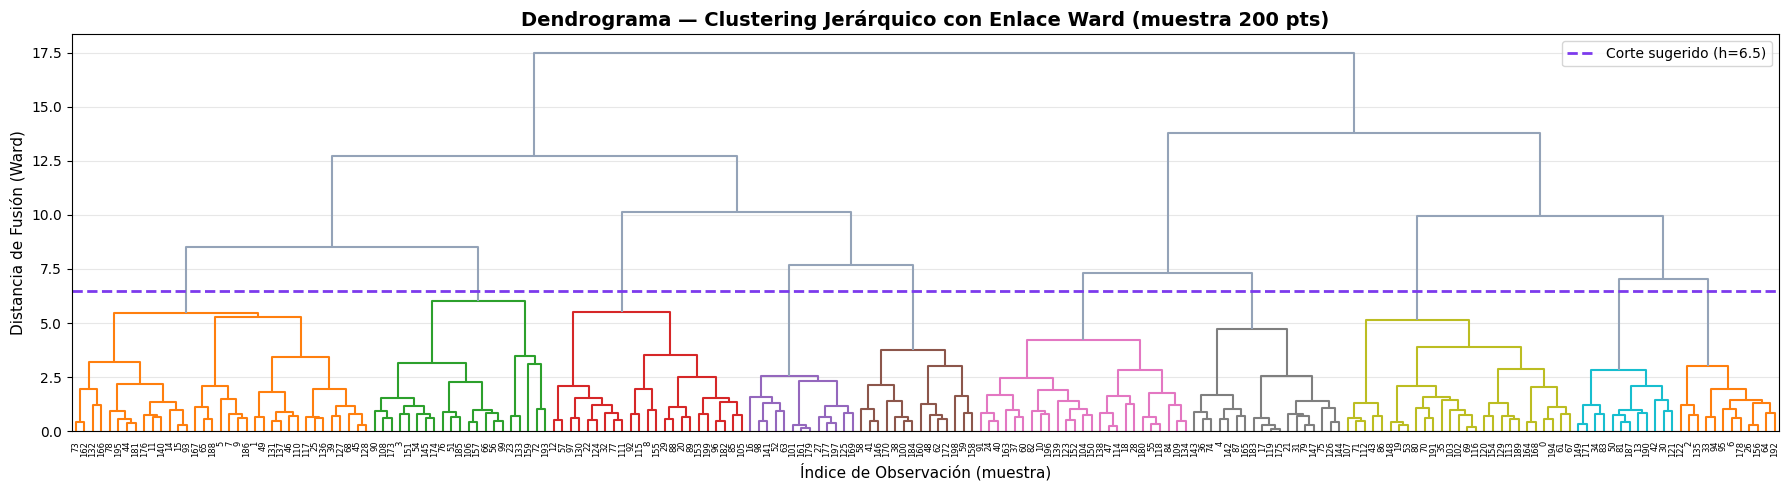

Número de fusiones mostradas: 199


In [2]:
# ─── Celda 2: Dendrograma con criterio Ward ──────────────────────────────────
# Usamos muestra de 200 puntos para el dendrograma (legibilidad)
np.random.seed(42)
idx_sample = np.random.choice(len(X_std), size=200, replace=False)
X_sample = X_std[idx_sample]

Z = linkage(X_sample, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(18, 5))
dendrogram(Z, ax=ax, leaf_rotation=90, leaf_font_size=6,
           color_threshold=6.5, above_threshold_color='#94a3b8')
ax.axhline(y=6.5, color='#7c3aed', linestyle='--', linewidth=2, label='Corte sugerido (h=6.5)')
ax.set_title('Dendrograma — Clustering Jerárquico con Enlace Ward (muestra 200 pts)', fontsize=14, fontweight='bold')
ax.set_xlabel('Índice de Observación (muestra)', fontsize=11)
ax.set_ylabel('Distancia de Fusión (Ward)', fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Número de fusiones mostradas: {len(Z)}")


---
##### 🛠️ Práctica 1: Corta el dendrograma para obtener K = 5

El dendrograma anterior se calculó en `Z` (matriz de enlace Ward de la muestra `X_sample`); la columna `Z[:, 2]` guarda la **altura de cada fusión**, ordenada de menor a mayor. Con ella puedes elegir la altura de corte $h$ para obtener un número de clusters concreto:

1. Con `fcluster(Z, t=6.5, criterion='distance')` corta a la altura de la línea punteada y cuenta cuántos clusters salen (`n_en_h65`).
2. Para obtener **exactamente 5** clusters, la altura de corte debe quedar entre la fusión `alturas[-5]` y la fusión `alturas[-4]` (las 4 últimas fusiones quedan por encima de la línea). Calcula `h_5` como el punto medio de esas dos alturas.
3. Corta con `h_5` (`labels_5`) y comprueba que hay 5 clusters.
4. Verifica que `fcluster(Z, t=5, criterion='maxclust')` produce **la misma partición**.

In [ ]:
# Escribe tu código aquí

# alturas = Z[:, 2]
# labels_h65 = fcluster(Z, t=6.5, criterion='distance')
# n_en_h65 = len(set(labels_h65))
# print("Clusters al cortar en h=6.5:", n_en_h65)

# h_5 = (alturas[-5] + alturas[-4]) / 2
# labels_5 = fcluster(Z, t=h_5, criterion='distance')
# assert len(set(labels_5)) == 5

# labels_5b = fcluster(Z, t=5, criterion='maxclust')
# pista: dos particiones iguales dan la misma tabla cruzada; cada cluster de uno cae entero en uno del otro

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
alturas = Z[:, 2]

# 1) Corte en h = 6.5 (la línea punteada del dendrograma)
labels_h65 = fcluster(Z, t=6.5, criterion='distance')
n_en_h65 = len(set(labels_h65))
print(f"Clusters al cortar en h=6.5: {n_en_h65}")

# 2) Altura que deja exactamente 5 clusters: entre las fusiones -5 y -4
h_5 = (alturas[-5] + alturas[-4]) / 2
print(f"Altura de corte para K=5: h = {h_5:.2f}")

# 3) Corte con h_5
labels_5 = fcluster(Z, t=h_5, criterion='distance')
assert len(set(labels_5)) == 5

# 4) Misma partición que pedir directamente 5 clusters
labels_5b = fcluster(Z, t=5, criterion='maxclust')
tabla = pd.crosstab(labels_5, labels_5b)
assert (tabla > 0).sum(axis=1).max() == 1 and (tabla > 0).sum(axis=0).max() == 1
print("Tamaños de los 5 clusters en la muestra:", np.bincount(labels_5)[1:])
```
</details>

---


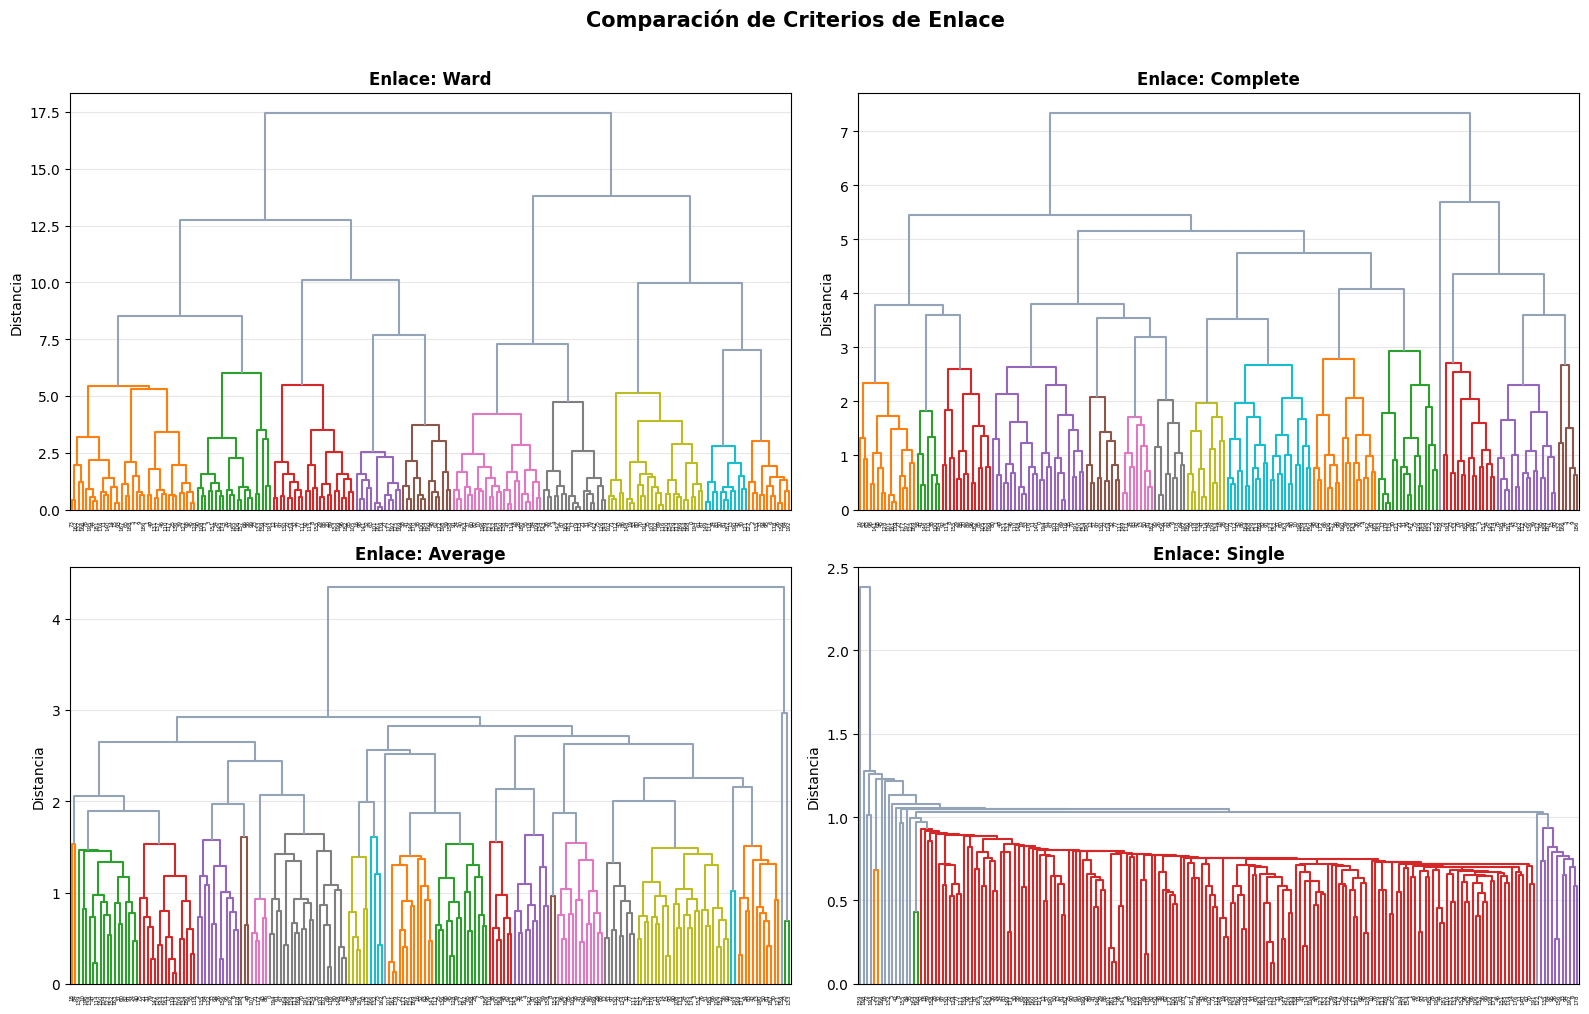

In [3]:
# ─── Celda 3: Comparación de criterios de enlace ─────────────────────────────
linkages = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
palette = ['#7c3aed', '#a855f7', '#ec4899', '#f59e0b', '#10b981']

for ax, method in zip(axes.flatten(), linkages):
    Z_m = linkage(X_sample, method=method, metric='euclidean')
    dendrogram(Z_m, ax=ax, leaf_rotation=90, leaf_font_size=4,
               color_threshold=0.4 * max(Z_m[:, 2]),
               above_threshold_color='#94a3b8')
    ax.set_title(f'Enlace: {method.capitalize()}', fontweight='bold')
    ax.set_ylabel('Distancia')
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Comparación de Criterios de Enlace', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
##### 🛠️ Práctica 2: ¿Qué criterio de enlace conviene? Silueta y efecto cadena

La celda anterior comparó los cuatro enlaces solo con dendrogramas (`linkages` guarda sus nombres). Ahora compáralos con **números**, sobre todo el dataset estandarizado `X_std` y con `K = 5`:

1. Para cada `method` en `linkages`, ajusta `AgglomerativeClustering(n_clusters=5, linkage=method)` y guarda el *Silhouette Score* y el **porcentaje de clientes que cae en el cluster más grande**.
2. Reúne los resultados en un `DataFrame` llamado `comparacion` (una fila por enlace) e imprímelo.
3. Comprueba el **efecto cadena** de `single`: casi todos los clientes terminan en un solo cluster (más del 90 %), mientras que con `ward` el cluster más grande tiene menos del 50 %.
4. Fíjate en la silueta de `single`: sale la más alta, pero el resultado es inútil. ¿Por qué hay que mirar también los tamaños?

In [ ]:
# Escribe tu código aquí

# filas = []
# for metodo in linkages:
#     lbl_m = AgglomerativeClustering(n_clusters=5, linkage=metodo).fit_predict(X_std)
#     filas.append({
#         'enlace': metodo,
#         'silhouette': ...,
#         'pct_cluster_mayor': 100 * np.bincount(lbl_m).max() / len(lbl_m),
#     })
# comparacion = pd.DataFrame(filas).set_index('enlace')
# print(comparacion.round(3))

# Comprobaciones con assert sobre comparacion.loc['single', ...] y comparacion.loc['ward', ...]

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
filas = []
for metodo in linkages:
    lbl_m = AgglomerativeClustering(n_clusters=5, linkage=metodo).fit_predict(X_std)
    filas.append({
        'enlace': metodo,
        'silhouette': silhouette_score(X_std, lbl_m),
        'pct_cluster_mayor': 100 * np.bincount(lbl_m).max() / len(lbl_m),
    })
comparacion = pd.DataFrame(filas).set_index('enlace')
print(comparacion.round(3))

# Efecto cadena: single mete casi todo en un solo cluster
assert comparacion.loc['single', 'pct_cluster_mayor'] > 90
assert comparacion.loc['ward', 'pct_cluster_mayor'] < 50

# single tiene la silueta más alta, pero es engañosa: 4 clusters son casi puntos sueltos
print("\nMayor silueta:", comparacion['silhouette'].idxmax(), "-> pero con un cluster del",
      f"{comparacion.loc['single', 'pct_cluster_mayor']:.1f}% de los clientes.")
```
</details>

---


Clustering Jerárquico Ward | K=5 | Silhouette Score: 0.1717


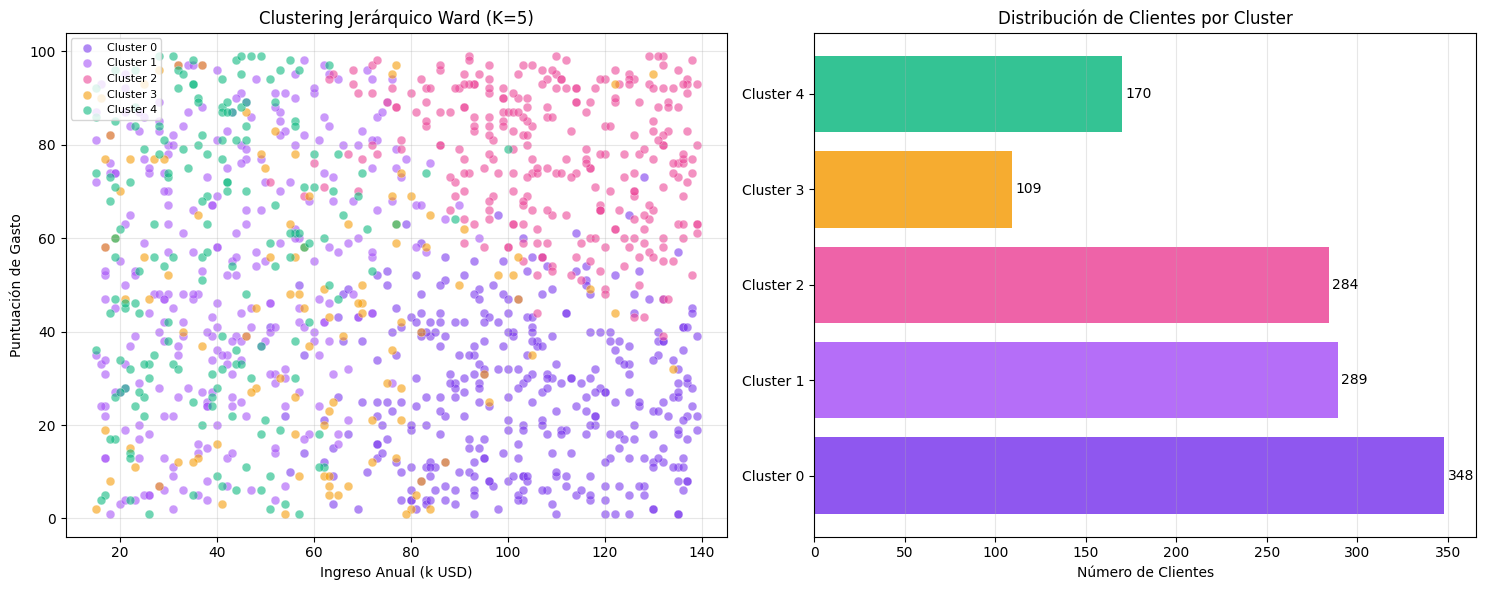


Características por cluster (medias):
              edad  ingreso_anual_k_usd  puntuacion_gasto  visitas_mensuales
cluster_hier                                                                
0             43.1                103.4              26.4                3.7
1             31.8                 43.5              52.7                4.2
2             47.2                109.3              77.6                3.8
3             56.4                 60.1              43.6                6.8
4             53.5                 40.0              56.4                2.3


In [4]:
# ─── Celda 4: Clustering final + Silhouette Score ────────────────────────────
K = 5
hclust = AgglomerativeClustering(n_clusters=K, linkage='ward')
labels = hclust.fit_predict(X_std)
df['cluster_hier'] = labels

sil = silhouette_score(X_std, labels)
print(f"Clustering Jerárquico Ward | K={K} | Silhouette Score: {sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for k in range(K):
    mask = labels == k
    axes[0].scatter(df.loc[mask, 'ingreso_anual_k_usd'], df.loc[mask, 'puntuacion_gasto'],
                    label=f'Cluster {k}', color=palette[k], alpha=0.6, s=40, edgecolors='white', linewidths=0.3)
axes[0].set_xlabel('Ingreso Anual (k USD)')
axes[0].set_ylabel('Puntuación de Gasto')
axes[0].set_title(f'Clustering Jerárquico Ward (K={K})')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Tamaño de clusters
sizes = [np.sum(labels == k) for k in range(K)]
axes[1].barh([f'Cluster {k}' for k in range(K)], sizes, color=palette[:K], alpha=0.85)
axes[1].set_xlabel('Número de Clientes')
axes[1].set_title('Distribución de Clientes por Cluster')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(sizes):
    axes[1].text(v + 2, i, str(v), va='center')

plt.tight_layout()
plt.show()

print("\nCaracterísticas por cluster (medias):")
resumen = df.groupby('cluster_hier')[features].mean().round(1)
print(resumen.to_string())


---
##### 🛠️ Práctica 3: ¿Se parecen el jerárquico y K-Means?

El resultado final del jerárquico está en `labels` (y en `df['cluster_hier']`). Compáralo con K-Means usando el mismo `K` y los mismos datos `X_std`:

1. Ajusta `KMeans(n_clusters=K, n_init=20, random_state=42)` y guarda sus etiquetas en `lbl_km_cmp`.
2. Construye la tabla cruzada `tabla = pd.crosstab(df['cluster_hier'], lbl_km_cmp)`.
3. Calcula la **pureza**: para cada cluster jerárquico toma el cluster de K-Means que más clientes le aporta (el máximo de su fila) y suma esos máximos; divídelo entre el total de clientes. Vale 1 si ambos agrupan idéntico.
4. Comprueba que la tabla suma `len(df)` y que `0 < pureza <= 1`. ¿Los dos algoritmos «piensan» igual en estos datos?

In [ ]:
# Escribe tu código aquí

# from sklearn.cluster import KMeans
# lbl_km_cmp = KMeans(n_clusters=K, n_init=20, random_state=42).fit_predict(X_std)
# tabla = pd.crosstab(df['cluster_hier'], lbl_km_cmp)
# print(tabla)

# pureza = ...    # pista: tabla.max(axis=1).sum() / tabla.values.sum()
# print(f"Pureza: {pureza:.3f}")

<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
from sklearn.cluster import KMeans

# 1) K-Means con el mismo K
lbl_km_cmp = KMeans(n_clusters=K, n_init=20, random_state=42).fit_predict(X_std)

# 2) Tabla cruzada jerárquico (filas) vs K-Means (columnas)
tabla = pd.crosstab(df['cluster_hier'], lbl_km_cmp)
print(tabla)

# 3) Pureza: fracción de clientes en el cluster K-Means dominante de su cluster jerárquico
pureza = tabla.max(axis=1).sum() / tabla.values.sum()
print(f"\nPureza: {pureza:.3f}")

# 4) Comprobaciones
assert tabla.values.sum() == len(df)
assert 0 < pureza <= 1
```
</details>

---


---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos · Data Mining · Módulo 03</i><br>
    Docente: Santiago A. Zúñiga M. | <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #7c3aed;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
  </p>
</div>